**Table of contents**<a id='toc0_'></a>    
- [Fluorescence lifetime and homo-FRET - A mathematical consideration](#toc1_)    
  - [Figure 2 e: Erlang distributions](#toc1_1_)    
  - [Figure 4: Simulations](#toc1_2_)    
      - [Modify transition matrix](#toc1_2_1_1_)    
      - [Get simulated true and simulated observed fluorescence lifetime](#toc1_2_1_2_)    
    - [Computationally predict observed and true fluorescence lifetime](#toc1_2_2_)    
    - [Figure 4 b, c](#toc1_2_3_)    
        - [Example 1 (2 fluorophores)](#toc1_2_3_1_1_)    
        - [Example 2 (4 fluorophores in rectangle)](#toc1_2_3_1_2_)    
        - [Example 3 (4 fluorophores in triangle and mid point)](#toc1_2_3_1_3_)    
      - [Figure 4 b - $T_{obs}$ is exponential](#toc1_2_3_2_)    
      - [Figure 4 c - $T_{S_{1}}$ is different to $T_{obs}$](#toc1_2_3_3_)    
    - [Figure 4 a - $T_{obs}$ and $T_{S_{1}}$ at different FRET rates](#toc1_2_4_)    
  - [Sympy - simplifying the expression](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Fluorescence lifetime and homo-FRET - A mathematical consideration](#toc0_)

In [ ]:
import warnings

import numpy as np
from scipy.stats import erlang, expon

import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.miscellaneous as mi
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

fluopy.figure version: 0.1.0
fluopy.simulation version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.fluorophores version: 0.1.0
fluopy.miscellaneous version: 0.1.0


## <a id='toc1_1_'></a>[Figure 2 e: Erlang distributions](#toc0_)
The convolution of multiple exponential distributions with the same rate parameter 
results in the Erlang distribution. The shape parameter represents the number of 
exponential distributions convolved. 

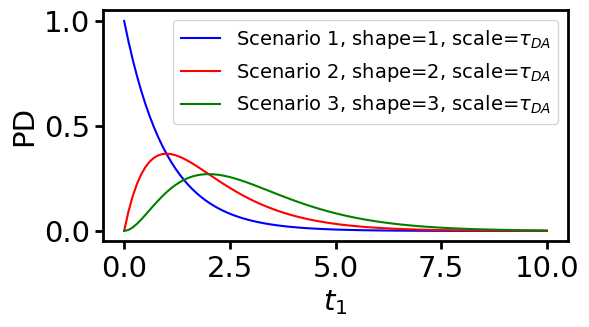

In [2]:
x = np.linspace(0, 10, 100)
y1 = erlang.pdf(x, a=1, loc=0, scale=1)  # scale is 1/rate, a is k
y2 = erlang.pdf(x, a=2, loc=0, scale=1)
y3 = erlang.pdf(x, a=3, loc=0, scale=1)

axes = fi.universal_figure(
    type_="line", data=[x, y1], label=r"Scenario 1, shape=1, scale=$\tau_{DA}$"
)
fi.universal_figure(
    type_="line",
    data=[x, y2],
    axes=axes,
    label=r"Scenario 2, shape=2, scale=$\tau_{DA}$",
    color="red",
)
fi.universal_figure(
    type_="line",
    data=[x, y3],
    axes=axes,
    xlabel=r"$t_{1}$",
    ylabel="PD",
    label=r"Scenario 3, shape=3, scale=$\tau_{DA}$",
    color="green",
)
axes[0, 0].legend(fontsize=14)
fig = mi.get_figure(axes)

fig.savefig("erlang_distribution.svg", bbox_inches="tight", dpi=300, pad_inches=0.1)

## <a id='toc1_2_'></a>[Figure 4: Simulations](#toc0_)
Assumes an infinitesimally short laser pulse that assures only one fluorophore to be excited per pulse. Another pulse
starts only if all fluorophores are in their ground state.
This simulation is suited to demonstrate the observed fluorescence lifetimes of homo-FRET experiments.
This simulation is NOT suited to demonstrate effects of energy transfers that are not homo-FRET, since they cannot
occur. Note: the observed fluorescence lifetime of systems without homo-FRET should equal the true fluorescence
lifetime.

#### <a id='toc1_2_1_1_'></a>[Modify transition matrix](#toc0_)

In [3]:
def modify_transition_matrix(transition_set):
    """
    Modifies the transition matrix in a way that prevents multiple fluorophores to be
    in a different photophysical state than the ground state simultaneously. This is
    achieved by setting all excitation rates that do not effect an all ground state
    fluorophore configuration to zero.
    """
    df = transition_set.combined_state_transitions_df
    excitations = df[df["abbreviation"] == "EXC"]
    indices_to_modify = excitations.index.values[
        transition_set.fluorophore_system.count :
    ]
    transition_rate_matrix = transition_set.transition_matrix * np.expand_dims(
        transition_set.row_sums, axis=1
    )
    transition_rate_matrix[:, indices_to_modify] = 0
    modified_row_sums = transition_rate_matrix.sum(axis=1)
    modified_transition_matrix = np.divide(
        transition_rate_matrix,
        np.expand_dims(modified_row_sums, axis=1),
        out=np.zeros_like(transition_rate_matrix),
        where=modified_row_sums != 0,
    )
    return modified_transition_matrix, modified_row_sums

#### <a id='toc1_2_1_2_'></a>[Get simulated true and simulated observed fluorescence lifetime](#toc0_)

In [4]:
def get_lifetimes(transition_series, time_series, transition_set):
    """
    True fluorescence lifetime: time between any excitation and fluorescent emission
    from the same fluorophore.
    Observed lifetimes: times between photon-driven excitation and fluorescent emission
    not considering whether the emission comes from the originally excited fluorophore.
    """
    df = transition_set.combined_state_transitions_df
    excitation_values = df[df["abbreviation"] == "EXC"].index.values
    fluorescence_values = df[df["abbreviation"] == "FLU"].index.values
    excitation_indices = np.isin(transition_series, excitation_values).nonzero()[0]
    emission_indices = np.isin(transition_series, fluorescence_values).nonzero()[0]
    excitation_times = time_series[excitation_indices + 1]
    emission_times = time_series[emission_indices + 1]
    pre_emission_times = time_series[emission_indices]
    true_lifetimes = emission_times - pre_emission_times
    corresponding_excitation_time_indices = (
        np.searchsorted(excitation_times, emission_times, side="right") - 1
    )
    corresponding_excitation_times = excitation_times[
        corresponding_excitation_time_indices
    ]

    observed_lifetimes = emission_times - corresponding_excitation_times

    return true_lifetimes, observed_lifetimes

### <a id='toc1_2_2_'></a>[Computationally predict observed and true fluorescence lifetime](#toc0_)

In [ ]:
def get_transition_probabilities(transition_df, fluorophore_system):
    """
    Gets the probabilities of homoFRET and fluorescent deexcitation and the true
    fluorescence lifetime. Note: the values returned reflect a setup where only one
    fluorophore is excited at a time. This means that if a fluorophore is in S1, all
    other fluorophores are, at all times, in S0. Hence, if the rate of homoFRET is
    non-zero, it has to be considered constantly and alters the true fluorescence
    lifetime and probability of fluorescence. Additionally, if more than 2 fluorophores
    are present, a total FRET rate is calculated depending on the distances.
    """
    _, occurrences = np.unique(
        list(fluorophore_system.distances.values()), return_counts=True
    )
    occurrences = occurrences / fluorophore_system.count
    df = transition_df
    fluorescence_rate = df[df["abbreviation"] == "FLU"]["rate"].values[0]
    non_et_s1_rates = df[df["initial_state"] == tr.SingleState.S1]["rate"]
    et_s1_s0_transitions = df[df["initial_state"] == tr.PairedState.S1_S0]
    et_s1_s0_rate_sum = 0
    for i, ((_, _), transition) in enumerate(et_s1_s0_transitions.iterrows()):
        et_s1_s0_rate_sum += transition["rate"] * occurrences[i]
    fluorescence_lifetime = 1 / (non_et_s1_rates.sum() + et_s1_s0_rate_sum)
    hfret_probability = et_s1_s0_rate_sum * fluorescence_lifetime
    fluorescence_probability = fluorescence_rate * fluorescence_lifetime

    return fluorescence_lifetime, hfret_probability, fluorescence_probability


def predict(transition_set, accuracy=10, size=10, seed=None):
    """
    Compute times between photon-driven excitation and fluorescent emission not
    considering whether the emission comes from the originally excited fluorophore.
    accuracy : int : The accuracy of the prediction. Higher energy transfer rates need
    higher accuracy to accomplish the same quality of prediction.
    """

    pred_tau, hfret_probability, fluorescence_probability = (
        get_transition_probabilities(
            transition_set.transition_df, transition_set.fluorophore_system
        )
    )
    rng = np.random.default_rng(seed)
    probabilities = []
    distributions = []
    for i in range(accuracy):
        probability = fluorescence_probability * hfret_probability**i  # x**0 = 1
        probabilities.append(probability)
        distribution = erlang(a=i + 1, scale=pred_tau)
        distributions.append(distribution)
    weights = probabilities / np.sum(
        probabilities
    )  # otherwise, probabilites do not add up to 1
    random_numbers = rng.uniform(0, 1, size)
    cumulative_probabilities = np.cumsum(weights)
    predicted_obs_lifetimes = np.ones(size)

    for i in range(size):
        index = np.searchsorted(cumulative_probabilities, random_numbers[i])
        predicted_obs_lifetimes[i] = distributions[index].rvs(size=1, random_state=rng)[
            0
        ]

    return pred_tau, predicted_obs_lifetimes

### <a id='toc1_2_3_'></a>[Figure 4 b, c](#toc0_)

##### <a id='toc1_2_3_1_1_'></a>[Example 1 (2 fluorophores)](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=2)
fluorophore_system_e1 = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1],
)
hfret = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=5e9,
    fluorophore_ids=[(0, 1), (1, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence],
    "D: fluorophore, A: fluorophore, dist: 10.0": [hfret],
}

transition_set_e1 = tr.TransitionSet(transitions, fluorophore_system_e1)
transition_set_e1.finalize()

mod_tm_e1, mod_rs_e1 = modify_transition_matrix(transition_set_e1)

start_at = tuple(np.zeros(shape=transition_set_e1.fluorophore_system.count, dtype=int))
df = transition_set_e1.combined_state_transitions_df
start_index = df[df["final_state"] == start_at].index[0]

time_series_e1, transition_series_e1 = si.direct_method_steps(
    transition_matrix=mod_tm_e1,
    row_sums=mod_rs_e1,
    start_index=start_index,
    size=int(3e7),
    seed=rng,
)

true_sim_tau_e1, obs_sim_tau_e1 = get_lifetimes(
    transition_series=transition_series_e1,
    time_series=time_series_e1,
    transition_set=transition_set_e1,
)

true_pred_tau_e1, pred_obs_tau_e1 = predict(
    transition_set=transition_set_e1, accuracy=int(1e6), size=1000, seed=rng
)

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


##### <a id='toc1_2_3_1_2_'></a>[Example 2 (4 fluorophores in rectangle)](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
fluorophores = fl.construct_fluorophores(name="fluorophore", distance=10, count=4)
fluorophore_system_e2 = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1, 2, 3]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1, 2, 3],
)
hfret = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=0.5e10,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3), (2, 0), (2, 3), (3, 1), (3, 2)],
)
hfret_2 = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=0.2e10,
    fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)],
)
transitions = {
    "fluorophore": [excitation, fluorescence],
    "D: fluorophore, A: fluorophore, dist: 10.0": [hfret],
    "D: fluorophore, A: fluorophore, dist: 14.142": [hfret_2],
}

transition_set_e2 = tr.TransitionSet(transitions, fluorophore_system_e2)
transition_set_e2.finalize()

mod_tm_e2, mod_rs_e2 = modify_transition_matrix(transition_set_e2)

start_at = tuple(np.zeros(shape=transition_set_e2.fluorophore_system.count, dtype=int))
df = transition_set_e2.combined_state_transitions_df
start_index = df[df["final_state"] == start_at].index[0]

time_series_e2, transition_series_e2 = si.direct_method_steps(
    transition_matrix=mod_tm_e2,
    row_sums=mod_rs_e2,
    start_index=start_index,
    size=int(3e7),
    seed=rng,
)

true_sim_tau_e2, obs_sim_tau_e2 = get_lifetimes(
    transition_series=transition_series_e2,
    time_series=time_series_e2,
    transition_set=transition_set_e2,
)

true_pred_tau_e2, pred_obs_tau_e2 = predict(
    transition_set=transition_set_e2, accuracy=int(1e6), size=1000, seed=rng
)

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


##### <a id='toc1_2_3_1_3_'></a>[Example 3 (4 fluorophores in triangle and mid point)](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
fluorophores = fl.construct_fluorophores(
    name="fluorophore", distance=10, count=3, shape="triangle"
)
fluorophore = fl.Fluorophore("fluorophore", position=[5, 2.88675])
fluorophores.append(fluorophore)
fluorophore_system_e3 = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1, 2, 3]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e9,
    fluorophore_ids=[0, 1, 2, 3],
)
hfret = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=0.5e10,
    fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)],
)
hfret_2 = tr.Transition(
    transition_type=tr.TransitionType.FRET,
    rate=1e10,
    fluorophore_ids=[(0, 3), (1, 3), (2, 3), (3, 0), (3, 1), (3, 2)],
)
transitions = {
    "fluorophore": [excitation, fluorescence],
    "D: fluorophore, A: fluorophore, dist: 10.0": [hfret],
    "D: fluorophore, A: fluorophore, dist: 5.774": [hfret_2],
}

transition_set_e3 = tr.TransitionSet(transitions, fluorophore_system_e3)
transition_set_e3.finalize()

mod_tm_e3, mod_rs_e3 = modify_transition_matrix(transition_set_e3)

start_at = tuple(np.zeros(shape=transition_set_e3.fluorophore_system.count, dtype=int))
df = transition_set_e3.combined_state_transitions_df
start_index = df[df["final_state"] == start_at].index[0]

time_series_e3, transition_series_e3 = si.direct_method_steps(
    transition_matrix=mod_tm_e3,
    row_sums=mod_rs_e3,
    start_index=start_index,
    size=int(3e7),
    seed=rng,
)

true_sim_tau_e3, obs_sim_tau_e3 = get_lifetimes(
    transition_series=transition_series_e3,
    time_series=time_series_e3,
    transition_set=transition_set_e3,
)

true_pred_tau_e3, pred_obs_tau_e3 = predict(
    transition_set=transition_set_e3, accuracy=int(1e6), size=1000, seed=rng
)

WARNING for line:             warnings.warn(
 Fluorophore fluorophore not known. Parameters have to be defined manually. 


#### <a id='toc1_2_3_2_'></a>[Figure 4 b - $T_{obs}$ is exponential](#toc0_)

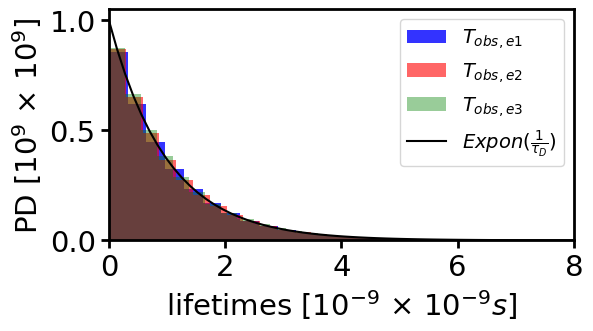

In [9]:
distr = expon(scale=1e-9)
ax = fi.universal_figure(
    type_="hist",
    data=obs_sim_tau_e1,
    label=r"$T_{obs,e1}$",
    density=True,
    bins=50,
    alpha=0.8,
)
ax = fi.universal_figure(
    type_="hist",
    data=obs_sim_tau_e2,
    label=r"$T_{obs,e2}$",
    density=True,
    bins=50,
    axes=ax,
    color="red",
    alpha=0.6,
)
ax = fi.universal_figure(
    type_="hist",
    data=obs_sim_tau_e3,
    label=r"$T_{obs,e3}$",
    density=True,
    bins=50,
    plot_distribution=distr,
    xlabel=r"lifetimes [$10^{-9}s$]",
    plot_distribution_label=r"$Expon(\frac{1}{\tau_{D}})$",
    ylabel=r"PD [$10^{9}$]",
    tick_style_y="sci",
    tick_style_x="sci",
    legend=True,
    axes=ax,
    color="green",
    alpha=0.4,
    xlim=[0, 8e-9],
)
ax[0, 0].legend(fontsize=14)
fig = mi.get_figure(ax)

fig.savefig("obs_tau_distr.svg", bbox_inches="tight", dpi=300, pad_inches=0.1)

#### <a id='toc1_2_3_3_'></a>[Figure 4 c - $T_{S_{1}}$ is different to $T_{obs}$](#toc0_)

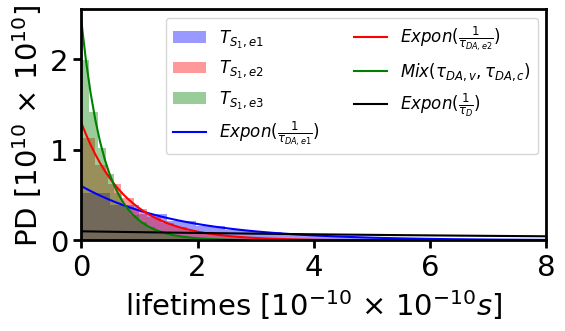

In [10]:
def pdf_e3(x, a, b, c):
    distr1 = (
        (3 * a + c) / (6 * a + 6 * b + 4 * c) * (c + 3 * a) * np.exp(-x * (c + 3 * a))
    )
    distr2 = (
        3
        * (a + 2 * b + c)
        / (6 * a + 6 * b + 4 * c)
        * (c + a + 2 * b)
        * np.exp(-x * (c + a + 2 * b))
    )
    return distr1 + distr2


distr1 = expon(scale=np.mean(true_pred_tau_e1))
distr2 = expon(scale=np.mean(true_pred_tau_e2))
x = np.linspace(0, 8e-10, 100)
distr3 = pdf_e3(a=1e10, b=0.5e10, c=1e9, x=x)
orig_distr = expon(scale=1e-9)
ax = fi.universal_figure(
    type_="hist",
    data=true_sim_tau_e1,
    label=r"$T_{S_{1},e1}$",
    density=True,
    bins=50,
    alpha=0.4,
)
ax = fi.universal_figure(
    type_="hist",
    data=true_sim_tau_e2,
    label=r"$T_{S_{1},e2}$",
    density=True,
    bins=50,
    axes=ax,
    color="red",
    alpha=0.4,
)
ax = fi.universal_figure(
    type_="hist",
    data=true_sim_tau_e3,
    label=r"$T_{S_{1},e3}$",
    density=True,
    bins=50,
    xlabel=r"lifetimes [$10^{-10}s$]",
    ylabel=r"PD [$10^{10}$]",
    tick_style_y="sci",
    tick_style_x="sci",
    legend=True,
    axes=ax,
    color="green",
    alpha=0.4,
    xlim=[0, 8e-10],
)
ax[0, 0].plot(x, distr1.pdf(x), label=r"$Expon(\frac{1}{\tau_{DA,e1}})$", color="blue")
ax[0, 0].plot(x, distr2.pdf(x), label=r"$Expon(\frac{1}{\tau_{DA,e2}})$", color="red")
ax[0, 0].plot(x, distr3, label=r"$Mix(\tau_{DA,v},\tau_{DA,c})$", color="green")
ax[0, 0].plot(x, orig_distr.pdf(x), label=r"$Expon(\frac{1}{\tau_{D}})$", color="black")
ax[0, 0].legend(fontsize=12, ncol=2)

fig = mi.get_figure(ax)
fig.savefig("true_tau_distr.svg", bbox_inches="tight", dpi=300, pad_inches=0.1)

### <a id='toc1_2_4_'></a>[Figure 4 a - $T_{obs}$ and $T_{S_{1}}$ at different FRET rates](#toc0_)

WARNING for line:             warnings.warn(
 Fluorophore fluorphore not known. Parameters have to be defined manually. 


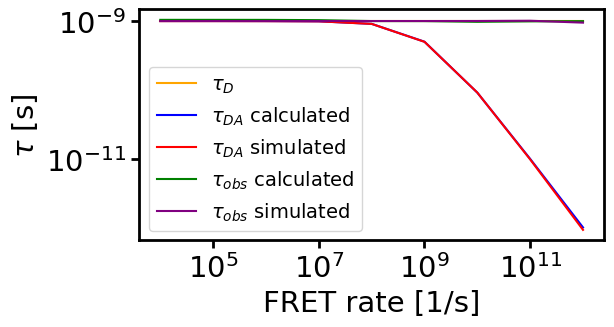

In [ ]:
rng = np.random.default_rng(1)
energy_transfer_rates = np.logspace(4, 12, num=9)
fluorophores = fl.construct_fluorophores("fluorphore", 10, 2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e9, fluorophore_ids=[0, 1]
)
fluorescence = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=3e8,
    fluorophore_ids=[0, 1],
)
ic = tr.Transition(
    transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
    rate=7e8,
    fluorophore_ids=[0, 1],
)

pred_true_lifetimes = []
pred_obs_lifetimes = []
unchanged_lifetimes = []
sim_obs_lifetimes = []
sim_true_lifetimes = []
for energy_transfer_rate in energy_transfer_rates:
    hfret = tr.Transition(
        transition_type=tr.TransitionType.FRET,
        rate=energy_transfer_rate,
        fluorophore_ids=[(0, 1), (1, 0)],
    )
    transitions = {
        "fluorphore": [excitation, fluorescence, ic],
        "D: fluorphore, A: fluorphore, dist: 10.0": [hfret],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    mod_transition_matrix, mod_row_sums = modify_transition_matrix(transition_set)
    start_at = tuple(np.zeros(shape=transition_set.fluorophore_system.count, dtype=int))
    df = transition_set.combined_state_transitions_df
    start_index = df[df["final_state"] == start_at].index[0]

    time_series, transition_series = si.direct_method_steps(
        transition_matrix=mod_transition_matrix,
        row_sums=mod_row_sums,
        start_index=start_index,
        size=int(1e6),
        seed=rng,
    )
    true_tau, obs_tau = get_lifetimes(
        transition_series=transition_series,
        time_series=time_series,
        transition_set=transition_set,
    )
    pred_tau, predicted_obs_lifetimes = predict(
        accuracy=int(1e5),
        size=100,
        transition_set=transition_set,
        seed=rng,
    )

    pred_obs_lifetimes.append(np.mean(predicted_obs_lifetimes))
    pred_true_lifetimes.append(pred_tau)
    sim_obs_lifetimes.append(np.mean(obs_tau))
    sim_true_lifetimes.append(np.mean(true_tau))
    unchanged_lifetimes.append(1e-9)

axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, unchanged_lifetimes],
    yscale="log",
    xscale="log",
    color="orange",
    label=r"$\tau_{D}$",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, pred_true_lifetimes],
    axes=axes,
    label=r"$\tau_{DA}$ calculated",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, sim_true_lifetimes],
    axes=axes,
    color="red",
    label=r"$\tau_{DA}$ simulated",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, pred_obs_lifetimes],
    axes=axes,
    color="green",
    label=r"$\tau_{obs}$ calculated",
)
axes = fi.universal_figure(
    type_="line",
    data=[energy_transfer_rates, sim_obs_lifetimes],
    axes=axes,
    color="purple",
    label=r"$\tau_{obs}$ simulated",
    legend=True,
    xlabel="FRET rate [1/s]",
    ylabel=r"$\tau$ [s]",
)
axes[0, 0].legend(fontsize=14)

fig = mi.get_figure(axes)
fig.savefig(
    "lifetimes_at_different_FRET_rates.svg",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.1,
)

## <a id='toc1_3_'></a>[Sympy - simplifying the expression](#toc0_)

In [12]:
import sympy as sp

a, b = sp.symbols("a b")

p_1 = a / (a + b)
p_2 = (1 - p_1) / 2
p_3 = p_1 * p_2
p_4 = 1 - p_1 - p_2 - p_3

expr = (
    p_1 * (1 / (a + b))
    + p_2 * (1 / (a + b) + 1 / a)
    + p_3 * (2 / (a + b))
    + p_4 * (2 / (a + b) + 1 / a)
)
simplified_expr = sp.simplify(expr)
simplified_expr

1/a